# CLIPSeg Test on Fashion Dataset
Testing CLIPSeg zero-shot segmentation on our fashion images with garment part phrases

In [ ]:
# Install required packages (uncomment if needed)
# !pip install transformers pillow matplotlib opencv-python pandas

In [1]:
# Imports
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import os

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/sc/home/felix.boelter/miniconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda


In [2]:
# Load CLIPSeg model
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined").to(device).eval()

print("✓ CLIPSeg model loaded successfully!")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

✓ CLIPSeg model loaded successfully!


In [3]:
# Load your fashion dataset
# Update paths to match your actual data
images_dir = "viescore/extracted_images"
metadata_file = "viescore/metadata_edit.csv"

# Load metadata
df = pd.read_csv(metadata_file)
print(f"Loaded {len(df)} samples")
print("\nFirst 5 samples:")
df.head()

Loaded 77 samples

First 5 samples:


,image,prompt
0,images/image_000.png,"make a cropped blouse, add huge bow to the nec..."
1,images/image_001.png,"make it a cropped blouse, keep long sleeves, a..."
2,images/image_002.png,"remove sleeves, add peplum"
3,images/image_003.png,"remove sleeves, add frill to the hem in same f..."
4,images/image_004.png,divide into two pieces: a cropped top without ...


In [24]:
@torch.no_grad()
def clipseg_heatmap(pil_img, phrases, reduce="mean"):
  """
  Returns a soft heatmap in [0,1] at the model's output resolution.
  phrases: str or list[str]
  reduce: 'mean' or 'max' across phrases
  """
  if isinstance(phrases, str):
      phrases = [phrases]

  # Process each phrase separately and combine results
  heatmaps = []

  for phrase in phrases:
      # Pass single phrase with single image
      inputs = processor(
          text=[phrase],  # Single phrase in a list
          images=[pil_img],  # Single image in a list
          return_tensors="pt"
      ).to(device)

      logits = model(**inputs).logits  # Should be [1, 1, H, W]
      print(f"Logits shape: {logits.shape}")  # Debug print

      probs = logits.sigmoid()         # [1, 1, H, W]

      # Extract the 2D heatmap properly
      if len(probs.shape) == 4:  # [batch, queries, H, W]
          heat = probs[0, 0].detach().cpu().numpy()  # [H, W]
      elif len(probs.shape) == 3:  # [batch, H, W]
          heat = probs[0].detach().cpu().numpy()  # [H, W]
      else:
          print(f"Unexpected probs shape: {probs.shape}")
          # Try to reshape to square
          total_pixels = probs.numel()
          side_length = int(total_pixels ** 0.5)
          heat = probs.view(side_length, side_length).detach().cpu().numpy()

      print(f"Heat shape after extraction: {heat.shape}")  # Debug print

      # Ensure it's 2D
      if heat.ndim == 1:
          # Try to reshape to square
          side_length = int(len(heat) ** 0.5)
          if side_length * side_length == len(heat):
              heat = heat.reshape(side_length, side_length)
          else:
              print(f"Cannot reshape 1D array of length {len(heat)} to square")
              continue

      # Normalize to [0,1]
      heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
      heatmaps.append(heat)

  if not heatmaps:
      # Return a dummy 2D array if no valid heatmaps
      return np.zeros((64, 64), dtype=np.float32)

  # Combine multiple heatmaps
  if reduce == "max":
      final_heat = np.max(np.stack(heatmaps, axis=0), axis=0)
  else:
      final_heat = np.mean(np.stack(heatmaps, axis=0), axis=0)

  return final_heat

In [12]:
# Post-processing functions

def soften_mask(heat, thr=0.5, blur_px=5, sharpen=8.0):
  """
  heat: [H,W] float [0,1] from clipseg_heatmap
  1) keep pixels above threshold, 2) blur, 3) sigmoid sharpen around median
  Returns soft mask in [0,1].
  """
  keep = (heat >= thr).astype(np.float32)
  m = heat * keep
  if blur_px > 0:
      # Make sure blur kernel size is odd
      kernel_size = blur_px if blur_px % 2 == 1 else blur_px + 1
      m = cv2.GaussianBlur(m, (kernel_size, kernel_size), 0)

  if m.max() > m.min():  # Avoid division by zero
      med = np.median(m[m > 0]) if np.any(m > 0) else 0.5
      out = 1.0 / (1.0 + np.exp(-sharpen * (m - med)))  # soft edges
      out = (out - out.min()) / (out.max() - out.min() + 1e-8)
  else:
      out = m

  return out.astype(np.float32)

def show_overlay(pil_img, mask, alpha=0.5, title=""):
  """Visualize mask overlay on image"""
  img = np.array(pil_img.convert("RGB")) / 255.0

  # Resize mask to match image dimensions
  img_h, img_w = img.shape[:2]
  mask_resized = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_LINEAR)

  cmap = plt.get_cmap("jet")
  color = cmap(mask_resized)[..., :3]
  overlay = (1-alpha)*img + alpha*color

  plt.figure(figsize=(8, 6))
  plt.imshow(overlay)
  plt.title(title)
  plt.axis("off")
  plt.show()

In [13]:
# Fashion-specific part phrases
FASHION_PARTS = {
    "sleeves": ["sleeves", "long sleeves", "short sleeves", "sleeve"],
    "hem": ["hemline", "dress hem", "skirt hem", "bottom hem"],
    "cuffs": ["cuffs", "sleeve cuffs", "wrist cuffs"],
    "collar": ["collar", "neckline", "neck"],
    "pockets": ["pockets", "pocket"],
    "buttons": ["buttons", "button"],
    "waist": ["waist", "waistline"],
    "belt": ["belt", "belted"],
    "skirt": ["skirt"],
    "top": ["top", "blouse", "shirt"],
    "coat": ["coat", "jacket"],
    "bow": ["bow", "ribbon"],
    "frill": ["frill", "ruffle", "peplum"]
}

def extract_parts_from_prompt(prompt):
    """Extract fashion parts mentioned in the prompt"""
    prompt_lower = prompt.lower()
    found_parts = []
    
    for part, keywords in FASHION_PARTS.items():
        if any(keyword in prompt_lower for keyword in keywords):
            found_parts.append(part)
    
    return found_parts

# Test the extraction
sample_prompt = "make a cropped blouse, add huge bow to the neckline that is closed at the right side, it is closed up the narrow to the neck, keep the long sleeves"
parts = extract_parts_from_prompt(sample_prompt)
print(f"Sample prompt: {sample_prompt}")
print(f"Extracted parts: {parts}")

Sample prompt: make a cropped blouse, add huge bow to the neckline that is closed at the right side, it is closed up the narrow to the neck, keep the long sleeves
Extracted parts: ['sleeves', 'collar', 'top', 'bow']


Testing image: viescore/extracted_images/2.png
Prompt: make a cropped blouse, add huge bow to the neckline that is closed at the right side, it is closed up the narrow to the neck, keep the long sleeves
Image size: (1178, 1297)


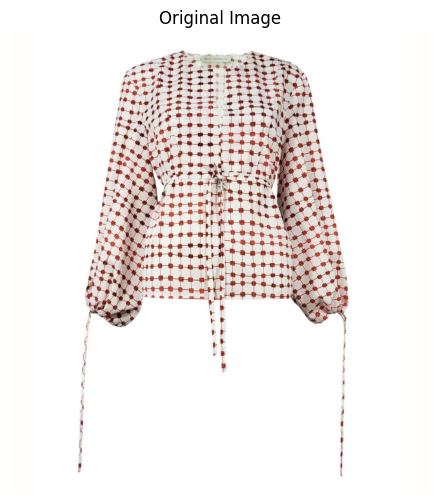

In [14]:
# Test on a single image
# Let's test on the first image
test_idx = 0
test_row = df.iloc[test_idx]

# Get the corresponding image (remember we added buffer of 2)
image_num = test_idx + 2  # Because image_000.png maps to 2.png
image_path = f"{images_dir}/{image_num}.png"

print(f"Testing image: {image_path}")
print(f"Prompt: {test_row['prompt']}")

# Load image
if os.path.exists(image_path):
    test_image = Image.open(image_path).convert("RGB")
    print(f"Image size: {test_image.size}")
    
    # Display original image
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()
else:
    print(f"Image not found: {image_path}")

Detected parts: ['sleeves', 'collar', 'top', 'bow']

Testing sleeves with phrases: ['sleeves', 'long sleeves', 'short sleeves', 'sleeve']


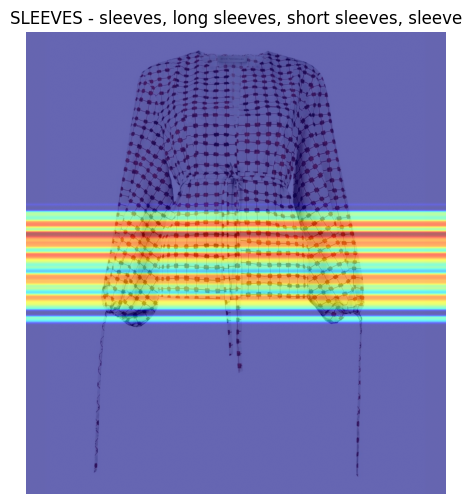


Testing collar with phrases: ['collar', 'neckline', 'neck']


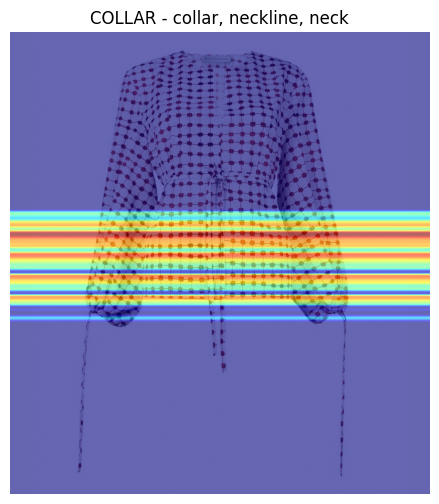


Testing top with phrases: ['top', 'blouse', 'shirt']


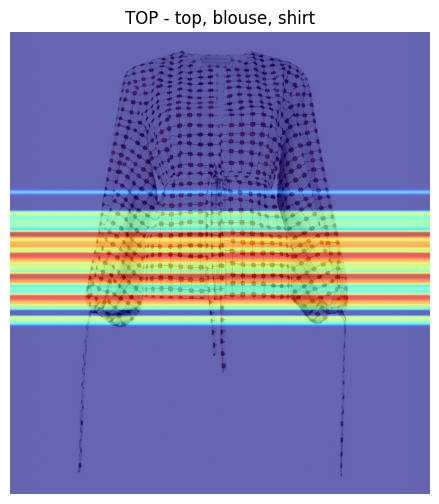


Testing bow with phrases: ['bow', 'ribbon']


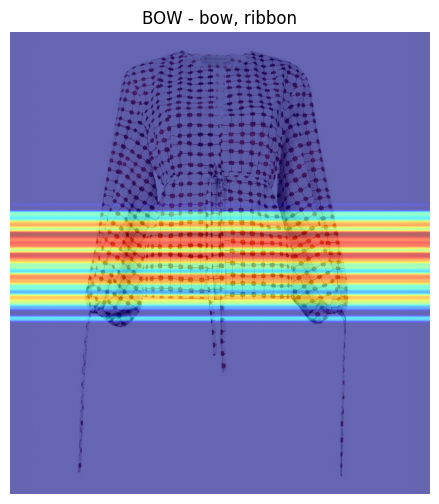

In [15]:
# Extract parts from the prompt and test segmentation
parts = extract_parts_from_prompt(test_row['prompt'])
print(f"Detected parts: {parts}")

# Test each part individually
for part in parts:
    if part in FASHION_PARTS:
        phrases = FASHION_PARTS[part]
        print(f"\nTesting {part} with phrases: {phrases}")
        
        # Generate heatmap
        heat = clipseg_heatmap(test_image, phrases, reduce="mean")
        
        # Create soft mask
        mask = soften_mask(heat, thr=0.4, blur_px=3, sharpen=6.0)
        
        # Show overlay
        show_overlay(test_image, mask, alpha=0.6, title=f"{part.upper()} - {', '.join(phrases)}")


Testing phrases: ['sleeves']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


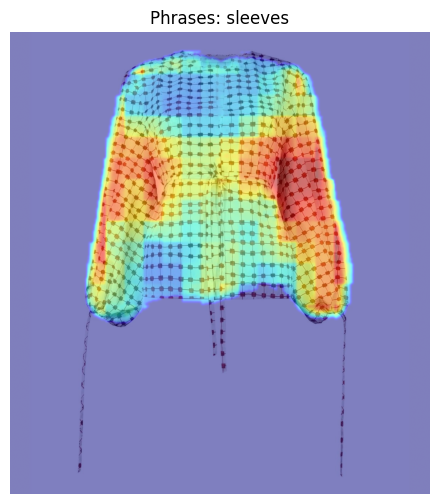


Testing phrases: ['collar', 'neckline']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


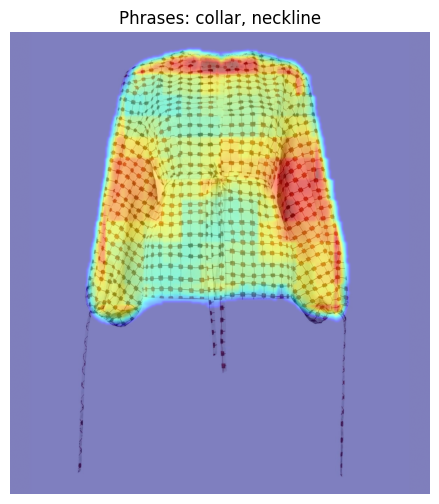


Testing phrases: ['hemline', 'bottom']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


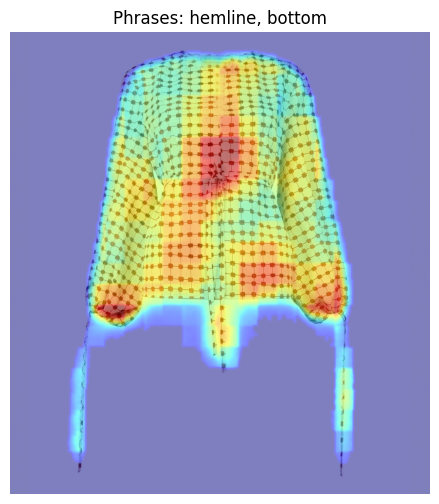


Testing phrases: ['waist']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


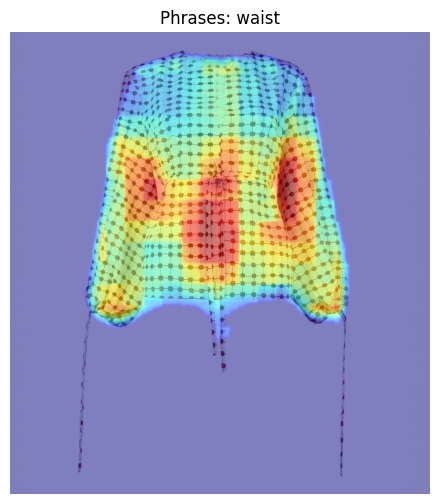


Testing phrases: ['dress']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


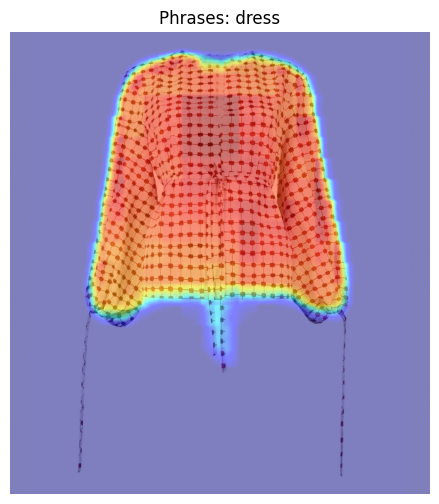


Testing phrases: ['fabric']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


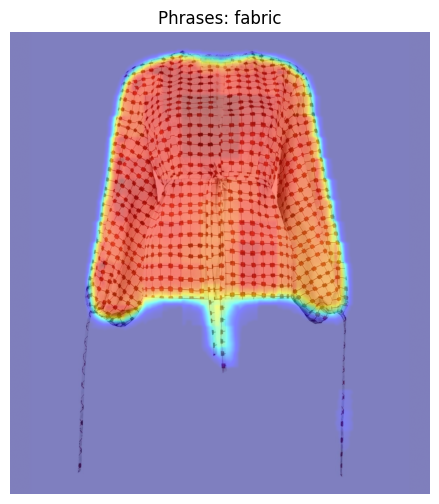


Testing phrases: ['buttons']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


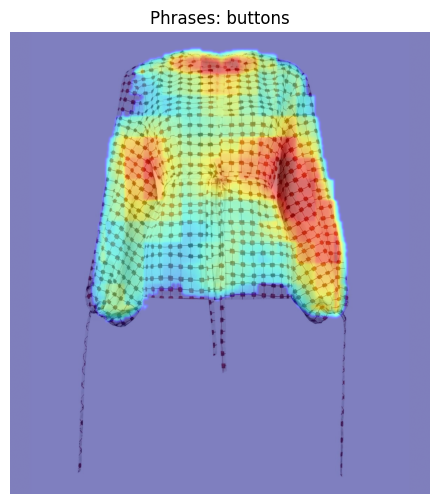

In [25]:
# Test with specific fashion keywords
# Let's try some common fashion terms
test_phrases = [
    ["sleeves"],
    ["collar", "neckline"],
    ["hemline", "bottom"],
    ["waist"],
    ["dress"],
    ["fabric"],
    ["buttons"]
]

for phrases in test_phrases:
    print(f"\nTesting phrases: {phrases}")
    
    heat = clipseg_heatmap(test_image, phrases, reduce="mean")
    mask = soften_mask(heat, thr=0.3, blur_px=3, sharpen=6.0)
    
    show_overlay(test_image, mask, alpha=0.5, title=f"Phrases: {', '.join(phrases)}")


Testing phrases: ['fabric', 'cloth', 'textile']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


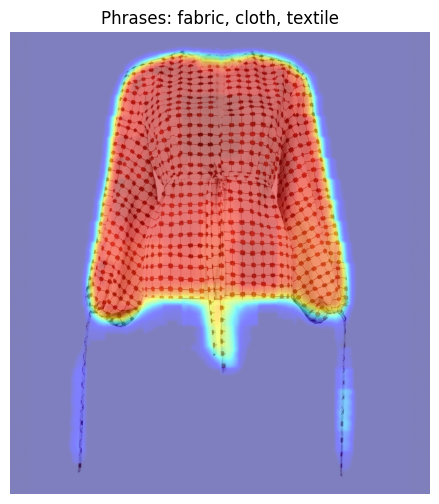


Testing phrases: ['edge', 'border', 'outline']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


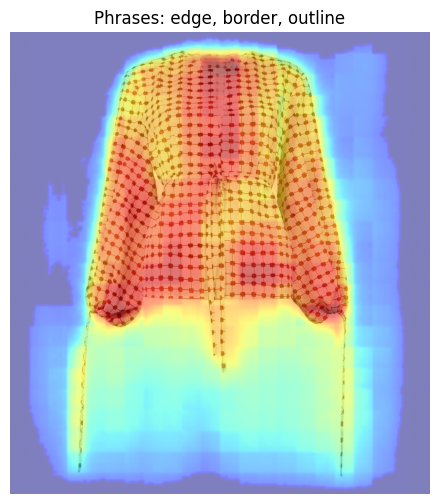


Testing phrases: ['top part', 'upper section']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


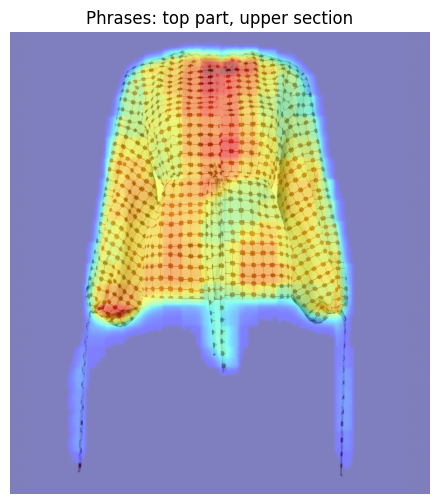


Testing phrases: ['bottom part', 'lower section']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


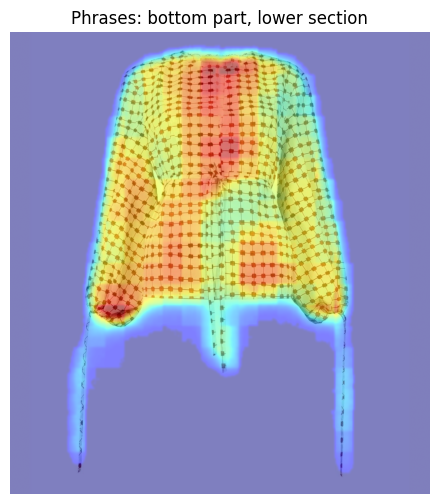


Testing phrases: ['arm covering', 'sleeves']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


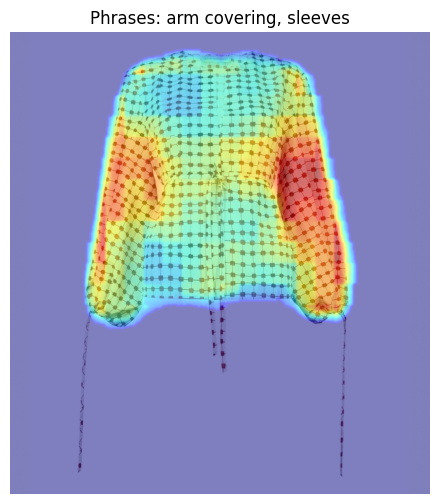


Testing phrases: ['neckline', 'collar area']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


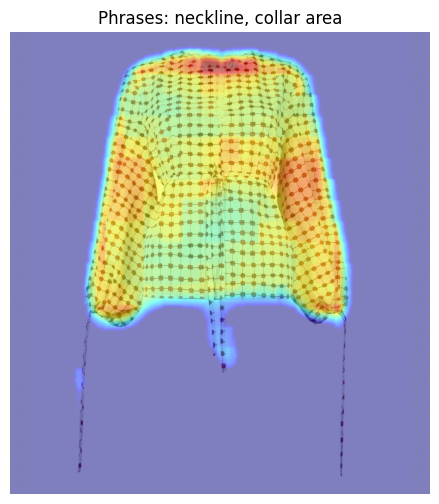


Testing phrases: ['decoration', 'detail', 'trim']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


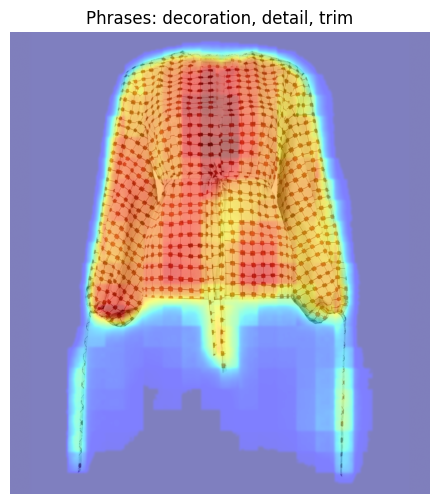

In [26]:
# Test with more visual/generic terms
test_phrases_visual = [
  ["fabric", "cloth", "textile"],
  ["edge", "border", "outline"],
  ["top part", "upper section"],
  ["bottom part", "lower section"],
  ["arm covering", "sleeves"],
  ["neckline", "collar area"],
  ["decoration", "detail", "trim"]
]

for phrases in test_phrases_visual:
  print(f"\nTesting phrases: {phrases}")

  heat = clipseg_heatmap(test_image, phrases, reduce="mean")
  mask = soften_mask(heat, thr=0.2, blur_px=3, sharpen=4.0)  # Lower threshold

  show_overlay(test_image, mask, alpha=0.5, title=f"Phrases: {', '.join(phrases)}")

Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


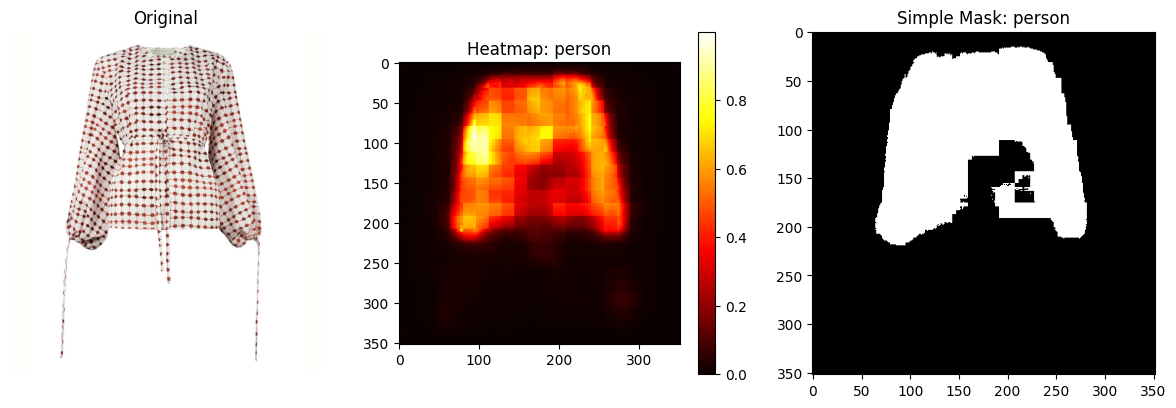

Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


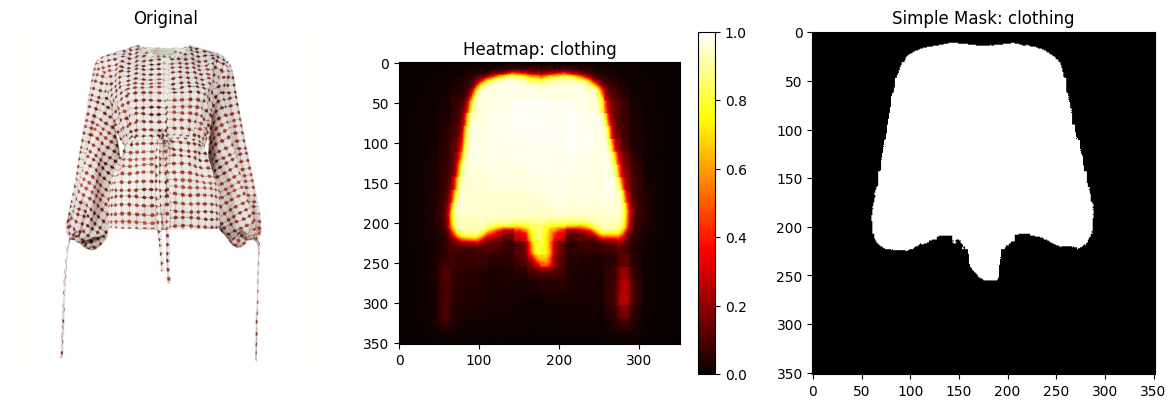

Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


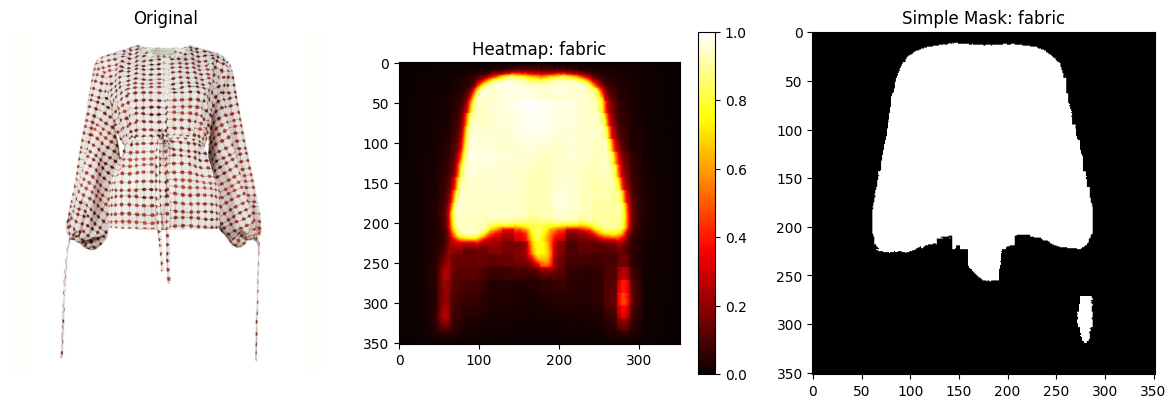

Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


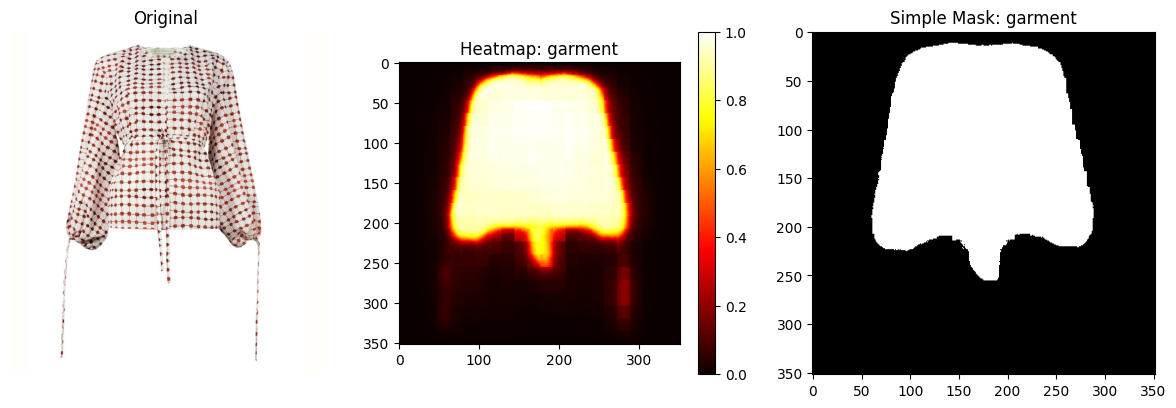

Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


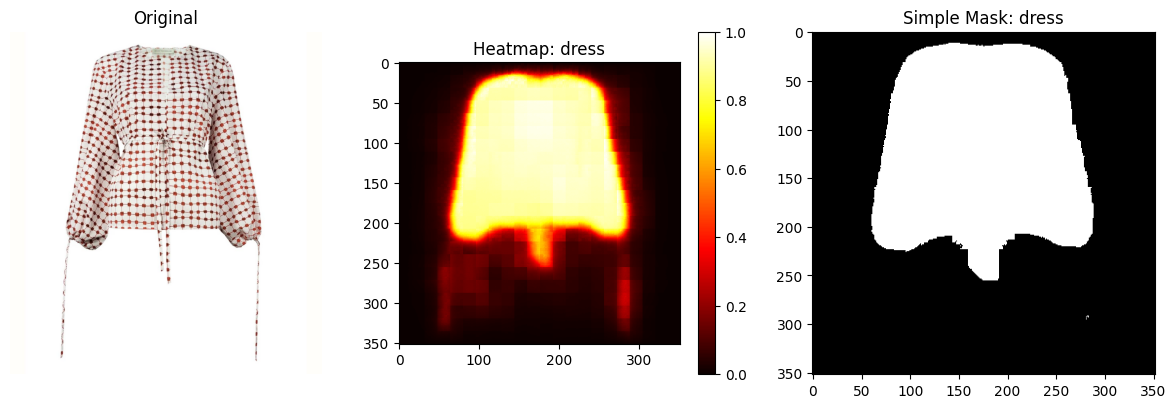

In [27]:
basic_tests = ["person", "clothing", "fabric", "garment", "dress"]

for term in basic_tests:
  heat = clipseg_heatmap(test_image, [term], reduce="mean")

  plt.figure(figsize=(12, 4))
  plt.subplot(1, 3, 1)
  plt.imshow(test_image)
  plt.title("Original")
  plt.axis("off")

  plt.subplot(1, 3, 2)
  plt.imshow(heat, cmap='hot')
  plt.title(f"Heatmap: {term}")
  plt.colorbar()

  # Very minimal processing
  simple_mask = (heat > 0.3).astype(float)
  plt.subplot(1, 3, 3)
  plt.imshow(simple_mask, cmap='gray')
  plt.title(f"Simple Mask: {term}")

  plt.tight_layout()
  plt.show()

Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


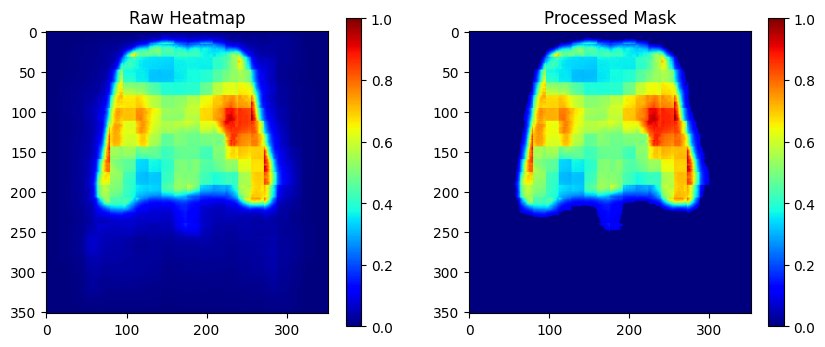

In [28]:
# Try with much lower threshold and less aggressive processing
heat = clipseg_heatmap(test_image, ["sleeves"], reduce="mean")

# Show raw heatmap first
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(heat, cmap='jet')
plt.title("Raw Heatmap")
plt.colorbar()

# Try very low threshold
mask = soften_mask(heat, thr=0.1, blur_px=1, sharpen=2.0)
plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='jet')
plt.title("Processed Mask")
plt.colorbar()
plt.show()



Image 1: viescore/extracted_images/2.png
Prompt: make a cropped blouse, add huge bow to the neckline that is closed at the right side, it is closed up the narrow to the neck, keep the long sleeves
Detected parts: ['sleeves', 'collar', 'top', 'bow']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


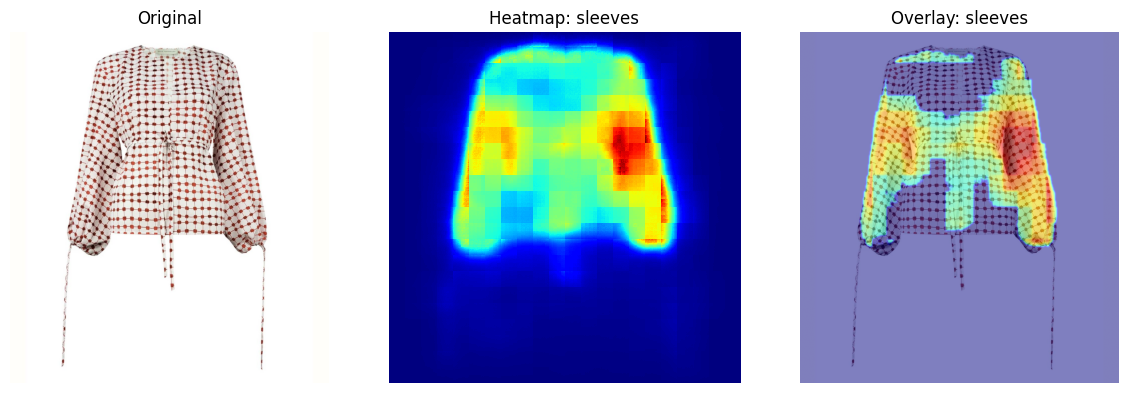


Image 2: viescore/extracted_images/3.png
Prompt: make it a cropped blouse, keep long sleeves, add a peplum like frill to the narrow neck line
Detected parts: ['sleeves', 'collar', 'top', 'frill']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


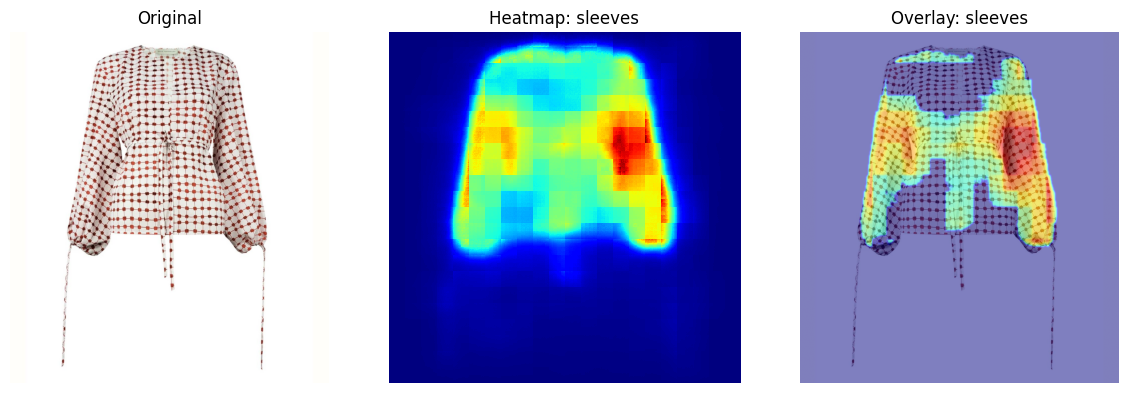


Image 3: viescore/extracted_images/4.png
Prompt: remove sleeves, add peplum
Detected parts: ['sleeves', 'frill']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


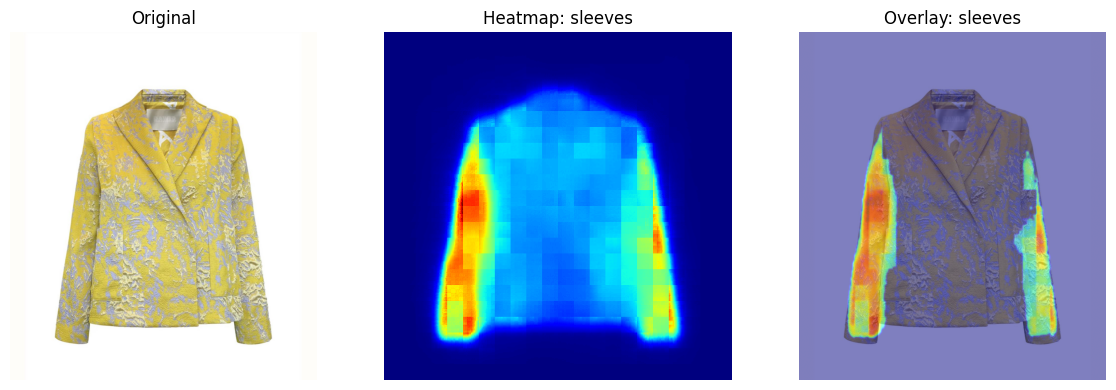


Image 4: viescore/extracted_images/5.png
Prompt: remove sleeves, add frill to the hem in same fabric
Detected parts: ['sleeves', 'frill']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


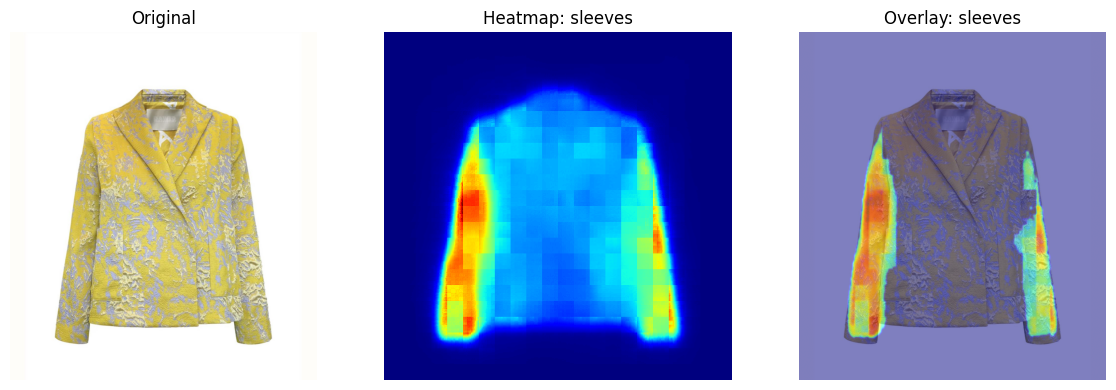


Image 5: viescore/extracted_images/6.png
Prompt: divide into two pieces: a cropped top without sleves and a long wide skirt with slit at center front that is belted at the waist, keep the silhouette of the initial coat
Detected parts: ['waist', 'belt', 'skirt', 'top', 'coat']
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)


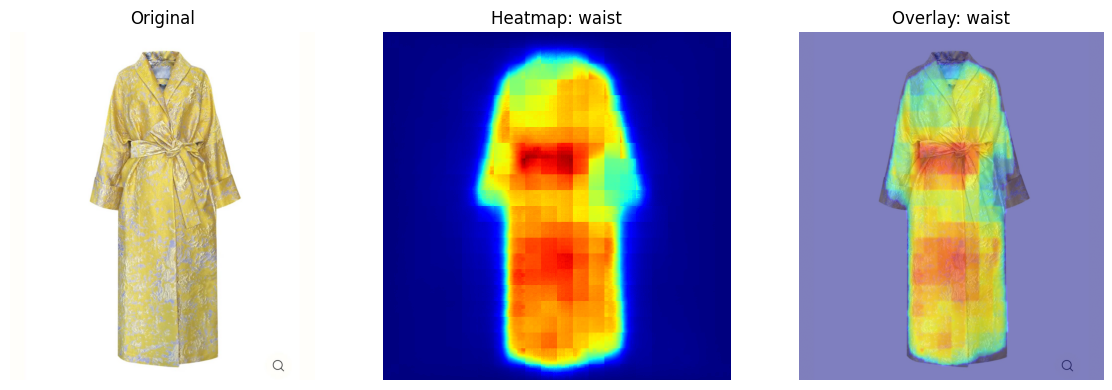

In [32]:
n_test = 5  # Number of images to test

for i in range(min(n_test, len(df))):
  row = df.iloc[i]
  image_num = i + 2  # Buffer of 2
  image_path = f"{images_dir}/{image_num}.png"

  if not os.path.exists(image_path):
      continue

  print(f"\n{'='*50}")
  print(f"Image {i+1}: {image_path}")
  print(f"Prompt: {row['prompt']}")

  image = Image.open(image_path).convert("RGB")
  parts = extract_parts_from_prompt(row['prompt'])

  print(f"Detected parts: {parts}")

  # Show original
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 3, 1)
  plt.imshow(image)
  plt.title("Original")
  plt.axis("off")

  # Generate mask for the most relevant part
  if parts:
      main_part = parts[0]  # Take first detected part
      phrases = FASHION_PARTS[main_part]

      heat = clipseg_heatmap(image, phrases, reduce="mean")
      mask = soften_mask(heat, thr=0.4, blur_px=3, sharpen=6.0)

      # Show heatmap
      plt.subplot(1, 3, 2)
      plt.imshow(heat, cmap='jet')
      plt.title(f"Heatmap: {main_part}")
      plt.axis("off")

      # Show overlay - RESIZE MASK TO MATCH IMAGE
      plt.subplot(1, 3, 3)
      img_array = np.array(image) / 255.0

      # RESIZE MASK TO MATCH IMAGE DIMENSIONS
      img_h, img_w = img_array.shape[:2]
      mask_resized = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_LINEAR)

      cmap = plt.get_cmap("jet")
      color = cmap(mask_resized)[..., :3]
      overlay = 0.5 * img_array + 0.5 * color
      plt.imshow(overlay)
      plt.title(f"Overlay: {main_part}")
      plt.axis("off")

  plt.tight_layout()
  plt.show()

In [35]:
def save_mask_results(df, images_dir, output_dir="clipseg_results", max_samples=10):
  """Save CLIPSeg results for further analysis - FIXED VERSION"""
  os.makedirs(output_dir, exist_ok=True)

  results = []

  for i in range(min(max_samples, len(df))):
      row = df.iloc[i]
      image_num = i + 2
      image_path = f"{images_dir}/{image_num}.png"

      if not os.path.exists(image_path):
          continue

      image = Image.open(image_path).convert("RGB")
      parts = extract_parts_from_prompt(row['prompt'])

      for part in parts:
          if part in FASHION_PARTS:
              phrases = FASHION_PARTS[part]

              # Generate mask
              heat = clipseg_heatmap(image, phrases, reduce="mean")
              mask = soften_mask(heat, thr=0.4, blur_px=3, sharpen=6.0)

              # Get image dimensions
              img_array = np.array(image) / 255.0
              img_h, img_w = img_array.shape[:2]

              # RESIZE MASK TO MATCH IMAGE DIMENSIONS
              mask_resized = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_LINEAR)

              # Save mask (resized)
              mask_filename = f"mask_{i:03d}_{part}.png"
              mask_path = os.path.join(output_dir, mask_filename)
              mask_pil = Image.fromarray((mask_resized * 255).astype(np.uint8))
              mask_pil.save(mask_path)

              # Save overlay (using resized mask)
              overlay_filename = f"overlay_{i:03d}_{part}.png"
              overlay_path = os.path.join(output_dir, overlay_filename)

              cmap = plt.get_cmap("jet")
              color = cmap(mask_resized)[..., :3]  # Use resized mask
              overlay = 0.5 * img_array + 0.5 * color
              overlay_pil = Image.fromarray((overlay * 255).astype(np.uint8))
              overlay_pil.save(overlay_path)

              results.append({
                  'image_idx': i,
                  'image_path': image_path,
                  'prompt': row['prompt'],
                  'part': part,
                  'phrases': ', '.join(phrases),
                  'mask_path': mask_path,
                  'overlay_path': overlay_path,
                  'mask_coverage': float(mask_resized.mean()),  # Use resized mask
                  'mask_max': float(mask_resized.max())  # Use resized mask
              })

  # Save results CSV
  results_df = pd.DataFrame(results)
  results_df.to_csv(os.path.join(output_dir, 'clipseg_results.csv'), index=False)

  print(f"Saved {len(results)} mask results to {output_dir}")
  return results_df
results_df = save_mask_results(df, images_dir, max_samples=10)
results_df.head()


Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])
Heat shape after extraction: (352, 352)
Logits shape: torch.Size([1, 352, 352])


,image_idx,image_path,prompt,part,phrases,mask_path,overlay_path,mask_coverage,mask_max
0,0,viescore/extracted_images/2.png,"make a cropped blouse, add huge bow to the nec...",sleeves,"sleeves, long sleeves, short sleeves, sleeve",clipseg_results/mask_000_sleeves.png,clipseg_results/overlay_000_sleeves.png,0.110359,0.999884
1,0,viescore/extracted_images/2.png,"make a cropped blouse, add huge bow to the nec...",collar,"collar, neckline, neck",clipseg_results/mask_000_collar.png,clipseg_results/overlay_000_collar.png,0.150219,0.999610
2,0,viescore/extracted_images/2.png,"make a cropped blouse, add huge bow to the nec...",top,"top, blouse, shirt",clipseg_results/mask_000_top.png,clipseg_results/overlay_000_top.png,0.231647,0.999524
3,0,viescore/extracted_images/2.png,"make a cropped blouse, add huge bow to the nec...",bow,"bow, ribbon",clipseg_results/mask_000_bow.png,clipseg_results/overlay_000_bow.png,0.122319,0.997990
4,1,viescore/extracted_images/3.png,"make it a cropped blouse, keep long sleeves, a...",sleeves,"sleeves, long sleeves, short sleeves, sleeve",clipseg_results/mask_001_sleeves.png,clipseg_results/overlay_001_sleeves.png,0.110359,0.999884


In [36]:
# Analyze results
print("CLIPSeg Results Summary:")
print(f"Total masks generated: {len(results_df)}")
print(f"\nMask coverage statistics:")
print(results_df['mask_coverage'].describe())
print(f"\nParts detected:")
print(results_df['part'].value_counts())

CLIPSeg Results Summary:
Total masks generated: 29

Mask coverage statistics:
count    29.000000
mean      0.118476
std       0.068664
min       0.006358
25%       0.072348
50%       0.110359
75%       0.150219
max       0.249587
Name: mask_coverage, dtype: float64

Parts detected:
part
top        7
sleeves    4
collar     3
frill      3
skirt      3
belt       3
coat       3
bow        1
waist      1
pockets    1
Name: count, dtype: int64
